In [ ]:
# You are developing a regression model to predict house prices.
# Dataset contains:
# House Size (sqft)
# Number of Tiles
# Total Construction Cost
# Number of Bedrooms
# Market Price
# After calculating correlation matrix, you find:
# House Size and Number of Tiles have 0.98 correlation
# Construction Cost is highly correlated (0.95) with House Size

# import pandas as pd

# data = pd.DataFrame({
#     'house_size': [1000, 1500, 2000, 2500, 3000],
#     'num_tiles': [100, 150, 200, 250, 300],
#     'construction_cost': [200000, 300000, 400000, 500000, 600000],
#     'num_bedrooms': [2, 3, 4, 5, 6],
#     'market_price': [220000, 320000, 420000, 520000, 620000],
# })

# data

import pandas as pd

data = pd.DataFrame({
    "house_size": [900, 1200, 1500, 1800, 2200, 2600, 3000],
    
    # Strong but not perfect correlation with house_size (~0.98)
    "num_tiles": [95, 130, 148, 190, 225, 255, 310],
    
    # High correlation with house_size (~0.95) but with noise
    "construction_cost": [185000, 255000, 295000, 365000, 445000, 515000, 610000],
    
    # Weaker correlation
    "num_bedrooms": [2, 3, 3, 4, 4, 5, 6],
    
    # Target variable
    "market_price": [210000, 280000, 330000, 410000, 510000, 580000, 690000]
})

data



,house_size,num_tiles,construction_cost,num_bedrooms,market_price
0,900,95,185000,2,210000
1,1200,130,255000,3,280000
2,1500,148,295000,3,330000
3,1800,190,365000,4,410000
4,2200,225,445000,4,510000
5,2600,255,515000,5,580000
6,3000,310,610000,6,690000


In [18]:
correlation_matrix = data.corr()
print(correlation_matrix)

                   house_size  num_tiles  construction_cost  num_bedrooms  \
house_size           1.000000   0.996756           0.998844      0.978225   
num_tiles            0.996756   1.000000           0.999118      0.985643   
construction_cost    0.998844   0.999118           1.000000      0.983026   
num_bedrooms         0.978225   0.985643           0.983026      1.000000   
market_price         0.998668   0.998877           0.999675      0.978848   

                   market_price  
house_size             0.998668  
num_tiles              0.998877  
construction_cost      0.999675  
num_bedrooms           0.978848  
market_price           1.000000  


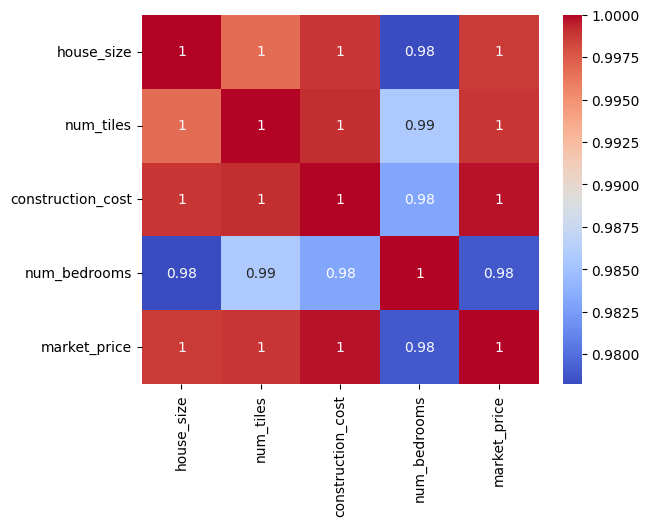

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [20]:
import numpy as np
upper = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column]>0.9)]

print("Highly correlated Featured to Drop:", to_drop) 

Highly correlated Featured to Drop: ['num_tiles', 'construction_cost', 'num_bedrooms', 'market_price']
